<a href="https://colab.research.google.com/github/rioodwyer1611/PythonProjects/blob/main/QuantumComputingLab_forStudents.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantum Computing Lab

This lab is structured into two parts. In Part A, you will be introduced to the basics of single qubit gates and measurements. You will use two python packages: Qutip for visualization, and Qiskit, for simulating quantum computation.

Part A has the following questions for a total of 5 points:

*   Question 1 (3 points)
*   Question 2 (1 point)
*   Question 3 (1 point)


Part B has the following questions for a total of 10 points:

*   Question 4 (4 points)
*   Question 5 (1 point)
*   Question 6 (4 point)
*   Question 7 (1 point)

Please note that answers to earlier questions may affect later questions. Please read lecture notes or seek advice from Applied Classes / Pracs if you need help.

In [ ]:
!pip install matplotlib
!pip install pylatexenc
!pip install qutip
!pip install qiskit
!pip install qiskit-aer

import math
import numpy as np
from pprint import pprint
from itertools import product
from functools import reduce
import operator


from qiskit import QuantumCircuit
from qiskit_aer import Aer
from qiskit.compiler import transpile
from qiskit.visualization import plot_histogram
from matplotlib import pyplot as plt
from qiskit.quantum_info import Statevector


# **PART A**: Basic quantum gates and measurements

Part A has the following questions for a total of 4 points:

*   Question 1
*   Question 2
*   Question 3


We will first explore the effect of single qubit quantum gates. Here, we represent a single qubit as a Bloch sphere. Quantum states are points on the surface of the sphere, which we show as arrows from the origin of the sphere to the surface. Quantum gates rotate quantum states to other quantum states, which we imagine as rotating an arrow to different parts of the sphere.

In [ ]:
import qutip
%matplotlib inline
import matplotlib.pyplot as plt
from qutip import Bloch, about, basis, mesolve, sigmam, sigmax, sigmay, sigmaz
from qutip.ipynbtools import plot_animation
from qutip.core.gates import t_gate, phasegate

# This code defines a sphere
b = qutip.Bloch()
b.make_sphere()
b.xlabel = [r'X, $|+\rangle$', r'']
b.ylabel = [r'Y', r'']
b.zlabel = [r'Z, $|0\rangle$', r'']
b.xlpos = [1.2, -1.2]
b.ylpos = [1.2, -1.2]

# This code defines single qubit gates
X = sigmax()
Y = sigmay()
Z = sigmaz()
T = t_gate()
S = phasegate(np.pi/2)
H = np.sqrt(1/2) * X + np.sqrt(1/2) * Z

# This code defines |0> state
ket_0 = (qutip.basis(2, 0) + (0+0j)*qutip.basis(2, 1)).unit()

# This code defines |+> = H |0> state
ket_final = H * ket_0

# This code plots |0>, |+> states
states = [ket_0, ket_final]
b.add_states(states)
b.add_arc(states[0], states[1])
b.show()

# You should now see single qubit states on a sphere, and the blue arc shows how the H-gate rotates |0> to |+>

Now we will see that we can prepare any single qubit state upto arbitrary precision as a sequence of $H$ and $T$ gates.  From Section 2.3 (notes), recall that Clifford + $T$ are univeral gate sets and $T^2=S$.

Here you can vary `TOTAL_SEQUENCE` and see the quantum states that we can produce by rotating $|0\rangle$ state by a random sequence of $H$ and $T$ gates.

In [ ]:
TOTAL_SEQUENCE=100

# This code defines a sphere.
b = qutip.Bloch()
b.make_sphere()
b.xlabel = [r'X', r'']
b.ylabel = [r'Y', r'']
b.xlpos = [1.4, -1.4]
b.ylpos = [1.4, -1.4]

# This code defines a list of random sequences of H and T gates with
# lengths = 1, 2, ...., TOTAL_SEQUENCE
points = [reduce(operator.mul, np.random.choice([T , H],size=repts))* ket_0
          for repts in range(1, TOTAL_SEQUENCE)]

# This code adds quantum states to the sphere as blue markers (shapes don't matter)
b.add_states(ket_0)
for idx, pt in enumerate(points):
  b.add_states(pt, kind="point", colors='b', alpha=1.0)
b.show()

The Bloch sphere represents a single qubit. However, we want to work with multiple qubits. We now prepare quantum states on multiple qubits and then compute the probability of measuring outcomes in the Pauli $Z$ basis.

To do this, we will use the Qiskit python package for simulating quantum computation and measurements. Let's first define the number of quantum bits we want to use.

In [ ]:
num_qubits = 3

Let's first create an empty circuit. Notice that each qubit is represented by a horizontal wire. Time flows from left to right on this wire.



In [ ]:
from qiskit import QuantumCircuit


qc = QuantumCircuit(num_qubits)
qc.draw('mpl')

I can apply single qubit gates by calling methods of `QuantumCircuit` object.

In [ ]:
def apply_X_gate(quantum_circuit, qubits):
  for q in qubits:
    quantum_circuit.x(q)

def apply_Y_gate(quantum_circuit, qubits):
  for q in qubits:
    quantum_circuit.y(q)

def apply_Z_gate(quantum_circuit, qubits):
  for q in qubits:
    quantum_circuit.z(q)

def apply_I_gate(quantum_circuit, qubits):
  pass

# Here I am applying X, X, H gate on qubit 1, 2 and 3 respectively
qc = QuantumCircuit(num_qubits)
apply_X_gate(qc, [0, 1]) # note indexing starts at 0
qc.h([2]) # so qubit 3 has an index of 2
qc.draw('mpl')



---


# **Question 1** (3 points)

Suppose I want to generate all possible bitstrings of length $n$ bits with equal probability. Using $n$ qubits, what is the quantum circuit that can generate this probability distribution?


---




In [ ]:
def my_function_1(quantum_circuit, qubits):
  # Q1 to-do
  # Hint: you only need the Hadamard gates
  pass

qc = QuantumCircuit(num_qubits)
my_function_1(qc, list(range(qc.num_qubits)))
qc.draw('mpl')

Let's measure these qubits and plot a histogram of distributions of bitstrings to verify our circuit.

In [ ]:
qc.measure_all()
qc.draw('mpl')

In experiments, we would run this circuit once, and obtain a single bitstring with probability $1/2^n$.

To obtain all possible outcomes, we have to prepare this quantum circuit, and measure it, many times. Let's set how many times we prepare and measure a quantum circuit below.  

In [ ]:
number_of_measurements = 10 # these are also called 'shots'.

We can now measure this quantum circuit using a simulator.

In [ ]:
from qiskit_aer import AerSimulator

sim = AerSimulator()
counts = sim.run(qc, shots=number_of_measurements).result().get_counts()
plot_histogram([counts], color=['midnightblue'],
                title="Output Histogram")



---


# **Question 2** (1 point)

Does the above histogram approximate a uniform distribution of all possible bitstrings of length $n$ bits?

Discuss what happens if you increase `number_of_measurements`.

---



When we measured the qubits above, we measured our qubits relative to the so-called *computational basis states*, $|0\rangle$ and $|1\rangle$. These states are associated with $Z$ operator since the $Z$ operator doesn't change them aside from a $\pm$ sign i.e. $Z|0\rangle = |0\rangle$ and $Z|1\rangle = -|1\rangle$.

The $Z$ operator is not so special. For example, we could measure our qubits  relative to the states $|+\rangle$ and $|-\rangle$ instead. These $|+\rangle$ and $|-\rangle$ states are associated with the $X$ operator because the operator leaves them alone aside from a sign i.e. $X|+\rangle = |+\rangle$ and $X|-\rangle = -|-\rangle$. This is called performing a measurement in the $X$ basis.

The following function shows how to measure in the $X$, $Y$, and the $Z$ basis.

In [ ]:
def measurement_basis(quantum_circuit, meas_basis):
  '''
  Rotate each qubit to the desired measurement basis before performing measurements.

  meas_basis: string 'X' or 'Y' or 'Z' for measurements in Pauli X, Y, or Z (computational) basis

  '''
  quantum_circuit.barrier()
  if meas_basis == 'X':
    quantum_circuit.h(range(quantum_circuit.num_qubits))
    # we are now measuring |+> and |-> basis
  elif meas_basis == 'Y':
    # we are now measuring |Y+> and |Y-> basis
    quantum_circuit.sdg(range(quantum_circuit.num_qubits))
    quantum_circuit.h(range(quantum_circuit.num_qubits))
  elif meas_basis == 'Z':
    # we are now measuring |0> and |1> basis
    pass
  else:
    raise ValueError('Invalid measurement basis')


Verify that if we measured the state (from Question 1) in the $X$ basis, we will only get one bitstring with probability 1.0. (You don't need to do anything if `my_function_1` from Question 1 is correct. Just run the cell below and look at the print output.)

In [ ]:
counts_list = []
legend_list = []
for basis in ['X', 'Y', 'Z']:
  qc = QuantumCircuit(num_qubits)
  my_function_1(qc, list(range(qc.num_qubits)))
  measurement_basis(qc, basis)
  state = Statevector(qc)
  qc.measure_all()
  qc.draw('mpl')
  counts = sim.run(qc, shots=1000).result().get_counts()
  counts_list.append(counts)
  legend_list.append(basis + ' basis')

  # Get exact Born probabilities for each bitstring in each measurement basis
  probs = state.probabilities_dict()
  print("Exact probability distribution in %s basis" %(basis))
  pprint(list(zip(probs.keys(), probs.values())))
  print()


plot_histogram(counts_list, legend = legend_list, color=['midnightblue', 'crimson', 'grey'],
                title="Comparison of different measurement bases")



---


# **Question 3** (1 point)

After preparing the state from Question 1, I tell whether I have measured in the $Y$ or $Z$ basis based on a histogram of measurements alone?

Answer: Discuss / write in words.



---



# **PART B**: Deutsch-Jozsa problem


Part B has the following questions for a total of 10 points:

*   Question 4 (4 points)
*   Question 5 (1 point)
*   Question 6 (4 point)
*   Question 7 (1 point)

Let's extend the constant vs. balanced function oracle problem to an $n$ bit input


---


  Input: a function $f:\{0,1\}^n \mapsto \{0,1\}$

  Promise: $f$ is either constant or balanced.

  Output: $0$ if $f$ is constant, $1$ if $f$ is balanced.


---


**A constant $f$** yields the same constant value irrespective of the input i.e. $f(x) = 0$ or $f(x) = 1$ for all bitstrings $x$. Notice that there are always only 2 constant functions for all $n$.

**A balanced $f$** gives $0$ for half of all possible input bits $x \in \{0,1\}^n$ and $1$ on the remaining half. Since there are $2^n$ possible values of $x$, a balanced function gives $0$ on half the input space of size $\frac{2^n}{2}  = 2^{n-1}$.

Notice that for $n\geq2$, not all functions are balanced nor constant. In fact, there are only 2 constant functions, and $\binom{ 2^n}{2^{n-1}}$ balanced functions. This is a small fraction of all possible $2^{2^n}$ boolean functions (for each input bitstring from ${2^n}$ possibilities, $f$ must output either 0 or 1 to define a truth table). The promise problem means that we can ignore functions that are neither constant nor balanced.

In [ ]:
for n in range(1,6):
  num_bal = math.comb(int(2**n), int(2**(n-1)))
  num_tot = 2**(2**n)
  percent = num_bal / num_tot
  print("Number of balanced functions for n=%s is %s out of a total of %s functions (%s)" %(n, num_bal, num_tot, np.round(percent, 3)))



 Consider $n=2$, where we have four possible values of $x \in \{00, 01, 10, 11 \}$. There are two constant functions (C1, C2) as before, but 6 possible balanced functions (B1-B6) where the output will be either 0 or 1 for half the input space.

|$x$  |     |$f$ |   |   |   |   |   |   |   |
| --- | --- | ---|---|---|---|---|---|---|---|
|$x_1$|$x_2$| C1 | C2| B1| B2| B3| B4| B5| B6|
| 0   | 0   |0   |1  |0  |1  |0  |1  |0  |1  |
| 0   | 1   |0   |1  |0  |1  |1  |0  |1  |0  |
| 1   | 0   |0   |1  |1  |0  |0  |1  |1  |0  |
| 1   | 1   |0   |1  |1  |0  |1  |0  |0  |1  |


 To obtain B1, notice that we can return the value of the first input $x_1$. For B3, notice we can return the value of the second input $x_2$. To obtain B5, notice we can add the inputs bits modulo 2 i.e. $x_1 \oplus x_2 $. For input strings $00, 11$, we get $0$ and for input strings $01, 10$, we get $1$.


 Notice that half of the functions are negations i.e. constant function C2 is a negation of C1, and balanced functions B2, B4, and B6 are negations of B1, B2, and B3.

 We will generalize this intuition and create constant and balanced oracles for $n>1$.



---

# **Question 4** (4 points)

In this question, you will encode an oracle as a quantum circuit. For any $n$ bit input, we add an extra ancilla qubit.

For $n=1$, we used:

*   an $I$ gate and an $X$ gate to represent a oracle returning a constant function i.e. ancilla output is unchanged (C1) or flipped (C2)
*   a $CX$ (aka CNOT) gate and an $X$ gate to represent a oracle returning a balanced function (B5), where CNOT gates entangled input qubits $x$ with an ancilla qubit $y$, i.e.  $CX |x, y \rangle = |x, x \oplus y\rangle $, and $x \oplus y$ is addition modulo 2.

For 𝑛=2, write the oracle functions C1 and B5 (Hint: you need only $I$, $X$, $CX$ gates). Use classical inputs ['00', '01', '10', '11'] to check that:

*    `constant_function` reproduces the truth table for C1 with probability 1
*    `balanced_function` reproduces the truth table for B5 with probability 1

Note that you have to write these functions.


In [ ]:
def constant_function(quantum_circuit, ancilla_bit):
  '''
  Return a constant that leaves ancilla qubit unchanged.
  Verify that this gives C1 for n=2.
  '''
  # Q4. Students to do
  pass


def balanced_function(quantum_circuit, ancilla_bit):
  '''
  Return a balanced function by adding bits in x (mod 2) i.e. x_1 + x_2 + .... + x_n (mod 2).
  Verify that this gives B5 for n=2.
  '''
  # Q4. Students to do
  pass


In [ ]:
num_bits=2

for func_name, test_func in zip (['C1', 'B5',],
                      [constant_function, balanced_function]):

  print('Testing function: %s '%(func_name))

  for classical_input in ['00', '01', '10', '11']:

    # This code makes a quantum circuit
    qc = QuantumCircuit(num_bits+1)

    # This code inputs a bit string x into the circuit
    for qindex, bit in enumerate(list(classical_input)):
      if int(bit):
        qc.x(qindex)

    # This code calls the oracle you wrote in Question 4
    qc.barrier()
    test_func(qc, num_bits)
    qc.barrier()

    # This code computes Born probabilities for all measurement outcomes
    state = Statevector(qc)
    probs = state.probabilities_dict()
    for key, val in probs.items():
      '''
      Note that Qiskit orders qubits, measurements, and other things by listing
      the lowest-numbered item last / on the right, a convention referred to as
      "little-endian". This means that the column below labeled "10" refers
      to counts where the first measurement yielded a "0", and the second
      measurements yielded a "1".
      '''
      if np.round(val, 2) != 0.0:
        output_measurement = key
        ancilla_msmt = output_measurement[0] # NB: little endian convention
        print("For input x=%s, the measurement on 3 qubits is %s for probability %s. The output f(x) on the ancilla is: %s "
              %(classical_input, output_measurement, val, ancilla_msmt))
  print()

Check that the output on the ancilla replicates the truth table for functions C1 and B5 on $n=2$.

Is there a way to sample randomly from all possible balanced functions (e.g. B1 to B6 for $n=2$)?

There might be more than one way to write such a function. Here's one example.

In [ ]:
def random_balanced_function(quantum_circuit, output_bit):

  '''
  Return a balance function randomly sampled from (2^n choose 2^(n-1))
  possible balanced functions defined for n bits.

  '''

  flip_qubits = np.random.choice(
      range(2**num_bits),  # numbers to sample from
      2**num_bits // 2,  # number of samples is half the input space
      replace=False,  # makes sure states are only sampled once
  )
  def add_random_x(quantum_circuit, bit_string):
      for qubit, bit in enumerate(reversed(bit_string)):
          if bit == "1":
              quantum_circuit.x(qubit)
      return quantum_circuit

  for state in flip_qubits:
    quantum_circuit = add_random_x(quantum_circuit, f"{state:0b}")
    quantum_circuit.mcx(list(range(quantum_circuit.num_qubits-1)), output_bit)
    quantum_circuit = add_random_x(quantum_circuit, f"{state:0b}")
    quantum_circuit.barrier()




---


# **Question 5** (1 point)

Use the code below to show that `random_balanced_function` generates the truth table for balanced functions B1, B2, B3, B4, B5, B6 with equal probability for $n=2$. How many bitstrings do you expect to see for arbitrary $n>2$?

Hint: you don't have to change much!

---



In [ ]:
num_bits = 2
num_trials = 1
output_dist = []

for random_trials in range(num_trials):
  trial_dist =[]

  # This code samples a random balanced function f
  rc = QuantumCircuit(num_bits+1)
  random_balanced_function(rc, num_bits)

  # This code plots the output f(x) for all input bits
  for classical_input in ['00', '01', '10', '11']:

    qc = QuantumCircuit(num_bits+1)
    for qindex, bit in enumerate(list(classical_input)):
      if int(bit):
        qc.x(qindex)
    qc.barrier()
    qc.compose(rc, inplace=True)
    qc.barrier()
    state = Statevector(qc)
    trial_dist += [str(k)[0] for k in state.probabilities_dict().keys()]

  # This code stores the output over num_trial repetitions
  output_dist += [''.join(trial_dist)]

# This code plots output f(x) over num_trial repetitions
plt.figure()
plt.title('Outputs of f(x) for x = 00, 01, 10, 11')
plt.hist(output_dist)
plt.show()



Now that we are convinced that we can generate a quantum circuit to represent  constant and balanced functions, we can write our final oracle function that randomly chooses a constant or balanced function.

In [ ]:
def dj_oracle(quantum_circuit, output_bit):

  # with 50% probability, choose a constant or (random) balanced function
  if np.random.randint(0, 2):
    secret_choice = 'Constant'
    constant_function(quantum_circuit, output_bit)
  else:
    secret_choice = 'Balanced'
    random_balanced_function(quantum_circuit, output_bit)

  # with 50% probability, negate the result
  if np.random.randint(0, 2):
    quantum_circuit.x(output_bit)

  return secret_choice

We now assert that the following quantum circuit solves the Deutsch Jozsa problem in a single quantum query.

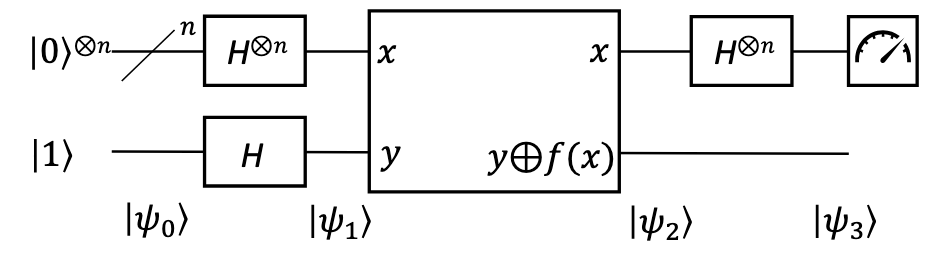

(Image credit: https://www.cl.cam.ac.uk/teaching/2324/QuantComp/Quantum_Computing_Lecture_7_2024.pdf)



---


# **Question 6** (4 points)
Implement the Deutsch Jozsa algorithm as a quantum circuit (use the picture above). Equivalently, we state that the Deutsch Jozsa algorithm is the following circuit:

$ (H^{\otimes n} \otimes I) U_f (H^{\otimes n} \otimes H)|0\rangle^{\otimes n} \otimes |1\rangle$

In the above, $U_f$ is the oracle function given by `dj_oracle`.

We state that if the all-zero case is measured on the topmost $n$-qubits, then the function is constant. In all other cases, the function is balanced.

---

For most of this lab, we have been trying to understand the construction of the quantum oracle (the middle box). Preparing this quantum oracle is part of preparing an input to the problem. Notice that implementing the rest of the algorithm is much easier!

In [ ]:
from qiskit import ClassicalRegister, QuantumRegister

num_bits=2


def run_algorithm(num_bits, oracle_func=dj_oracle, visualize=False):

  qr = QuantumRegister(num_bits + 1)
  cr = ClassicalRegister(num_bits)

  qc = QuantumCircuit(*[qr, cr])
  qc.barrier()
  # |Psi>_0
  # Student to code circuit
  qc.barrier()
  # |Psi>_1
  # Student to code circuit (hint: use Question 1)
  qc.barrier()
  # |Psi>_2
  secret_choice = oracle_func(qc, num_bits)
  qc.barrier()
  # |Psi>_3
  # Student to code circuit (hint: use Question 1)
  qc.barrier()
  qc.measure(qr[0: num_bits], cr)

  # measure the circuit
  result = AerSimulator().run(qc, shots=1, memory=True).result()
  measurement = result.get_memory()
  if visualize:
    display(qc.draw(output="mpl"))

  return measurement, secret_choice


measurement, secret_choice = run_algorithm(num_bits, visualize=True)
is_constant = np.all([int(x)==0 for x in measurement])

print('Actual Measurement', measurement)
print("Query Result:", ['Balanced', 'Constant'][int(is_constant)])
print("Secret Oracle:", secret_choice)

Now let's check that our oracle indeed gives all-zero case for constant functions 50% of the time, and all other measurement outcomes are for Balanced functions.

In [ ]:
measurement_outcomes = []
num_bits= 3
shots=5000
prob_constant = 0.5
prob_balanced = 0.5 * 1/(2**num_bits -1)


for random_trial in range(shots):
  measurement, secret_choice = run_algorithm(num_bits, visualize=False)
  is_constant = np.all([int(x)==0 for x in measurement])

  # check we got the right answer
  assert ['Balanced', 'Constant'][int(is_constant)] == secret_choice

  # store the measurement result
  measurement_outcomes += measurement

plt.figure()
plt.hist(measurement_outcomes, bins=2**num_bits,
         width=0.7)

plt.axhline(y= shots * prob_constant, label= 'Constant', ls='--', color='green')
plt.axhline(y= shots * prob_balanced, label= 'Balanced', ls='-.', color='red')
plt.legend(loc=0)
plt.show()


You can now check that the algorithm you implemented works for arbitrary $n$.




---
# **Question 7** (1 point)

 How many queries does a deterministic classical algorithm need to distinguish between a constant vs. balanced function? Explain why.


---



# Extra (not examinable)

Since we have worked so hard, we can use the same algorithm to solve a different task.

---


**Berstein-Vazirani problem**

Input: a function $f:\{0,1\}^n \mapsto \{0,1\}$

Promise: there exists a binary string $s$ for which $f(x)=s \cdot x$ for all $x, s \in \{0, 1\}^n$

Output: the string s



---



We will now change the oracle function for this problem.  The oracle is very similar to the function B5 that you implemented in Question 4.

In [ ]:
def bv_oracle(quantum_circuit, output_bit):
  '''
  Return a randomly generated string and implement its corresponding Berstein-Vazirani query as a quantum circuit
  '''
  input_bits = quantum_circuit.num_qubits - 1
  secret_choice = np.random.randint(2, size=input_bits)

  for q_index, q_val in enumerate(secret_choice[::-1]):
    if q_val:
      quantum_circuit.cx(q_index, output_bit)

  return ''.join([str(x) for x in secret_choice])

But we keep the DJ algorithm exactly the same to solve this task. You can verify whether this works using the code below:

In [ ]:
for num_bits in [1, 2, 3]:
  print("BV problem of input bitstring n=%s" %(num_bits))
  for _ in range(2 * 2** num_bits):
    # solve random instances of the problem
    measured_string, secret_string = run_algorithm(num_bits, oracle_func=bv_oracle, visualize=False)
    assert (secret_string == measured_string[0])
    print("True secret string s = %s and measured string %s" %(secret_string, measured_string[0]))
  print()